# Marketing Funnel & Conversion Analysis
### Dataset: Bank Marketing Campaign (Portugal Bank)
### Objective: Analyze customer conversion behavior and marketing funnel performance 

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')

In [4]:
import os
os.getcwd()

'C:\\Users\\georg'

In [13]:
df = pd.read_csv(r"C:\Users\georg\Downloads\bank-additional-full.csv")

In [14]:
df.shape

(41188, 21)

In [15]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [17]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')

In [18]:
# convert response to data form
df['converted'] = df['y'].map({'yes': 1, 'no': 0})

In [19]:
# check distribution
df['converted'].value_counts(normalize=True)

converted
0    0.887346
1    0.112654
Name: proportion, dtype: float64

In [20]:
# overall conversion rate
conversion_rate = df['converted'].mean()

print("Total Leads:", len(df))
print("Total Conversions:", df['converted'].sum())
print("Conversion Rate:", round(conversion_rate * 100, 2), "%")

Total Leads: 41188
Total Conversions: 4640
Conversion Rate: 11.27 %


In [21]:
# define funnel stages
df['engaged'] = np.where((df['previous'] > 0) | (df['poutcome'] == 'success'), 1, 0)

In [22]:
# build a funnel table
funnel = pd.DataFrame({
    "Stage": ["Contacted", "Engaged", "Converted"],
    "Count": [
        len(df),
        df['engaged'].sum(),
        df['converted'].sum()
    ]
})

funnel

,Stage,Count
0,Contacted,41188
1,Engaged,5625
2,Converted,4640


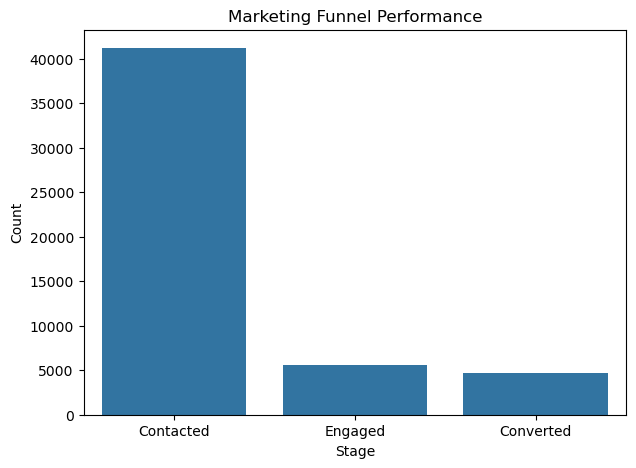

In [23]:
# visualize the funnel
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,5))
sns.barplot(data=funnel, x="Stage", y="Count")
plt.title("Marketing Funnel Performance")
plt.show()

In [24]:
# channel performance
channel = df.groupby('contact')['converted'].mean().sort_values(ascending=False)
channel

contact
cellular     0.147376
telephone    0.052313
Name: converted, dtype: float64

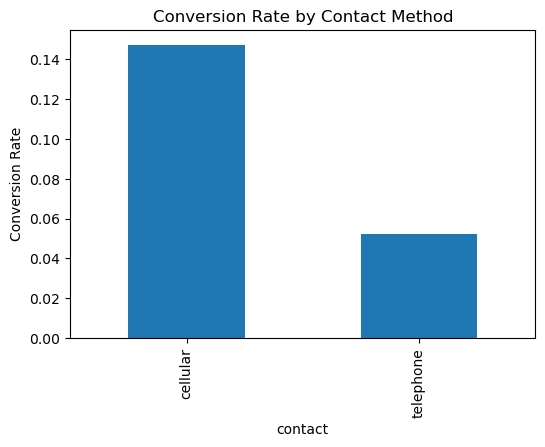

In [25]:
channel.plot(kind='bar', figsize=(6,4))
plt.title("Conversion Rate by Contact Method")
plt.ylabel("Conversion Rate")
plt.show()

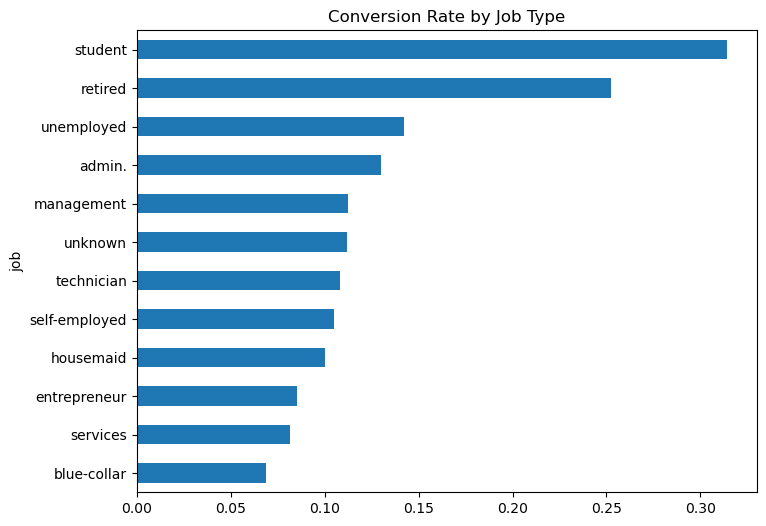

In [26]:
#job based analysis
job_conv = df.groupby('job')['converted'].mean().sort_values()

job_conv.plot(kind='barh', figsize=(8,6))
plt.title("Conversion Rate by Job Type")
plt.show()

In [27]:
# education impact
edu_conv = df.groupby('education')['converted'].mean().sort_values()

edu_conv

education
basic.9y               0.078246
basic.6y               0.082024
basic.4y               0.102490
high.school            0.108355
professional.course    0.113485
university.degree      0.137245
unknown                0.145003
illiterate             0.222222
Name: converted, dtype: float64

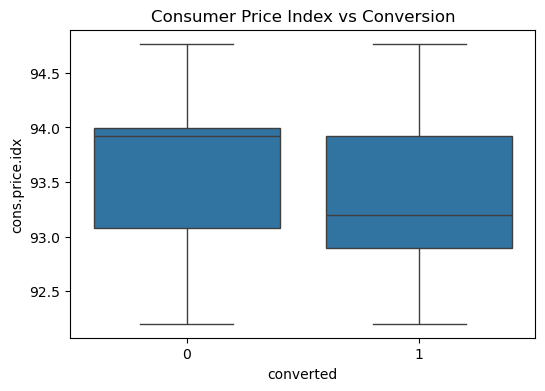

In [33]:
# consumer price index
plt.figure(figsize=(6,4))
sns.boxplot(x='converted', y='cons.price.idx', data=df)
plt.title("Consumer Price Index vs Conversion")
plt.show()

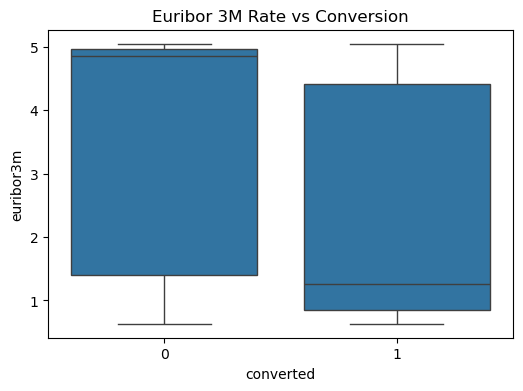

In [34]:
plt.figure(figsize=(6,4))
sns.boxplot(x='converted', y='euribor3m', data=df)
plt.title("Euribor 3M Rate vs Conversion")
plt.show()

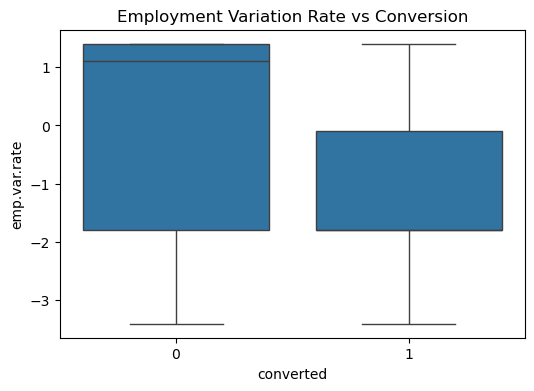

In [35]:
plt.figure(figsize=(6,4))
sns.boxplot(x='converted', y='emp.var.rate', data=df)
plt.title("Employment Variation Rate vs Conversion")
plt.show()

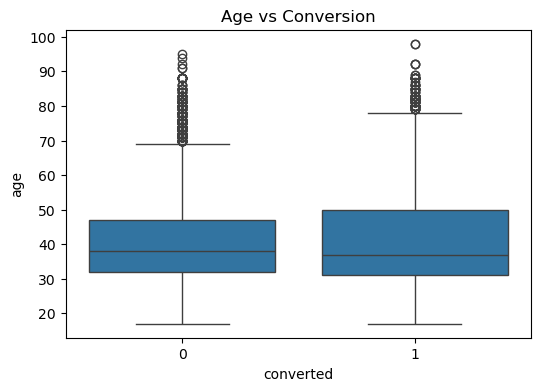

In [36]:
# age impact
plt.figure(figsize=(6,4))
sns.boxplot(x='converted', y='age', data=df)
plt.title("Age vs Conversion")
plt.show()

In [30]:
#campaign frequency effect
df.groupby('campaign')['converted'].mean().head(10)

campaign
1     0.130371
2     0.114570
3     0.107471
4     0.093927
5     0.075047
6     0.076609
7     0.060413
8     0.042500
9     0.060071
10    0.053333
Name: converted, dtype: float64

In [31]:
# drp-off analysis
df['converted'].value_counts(normalize=True)

converted
0    0.887346
1    0.112654
Name: proportion, dtype: float64

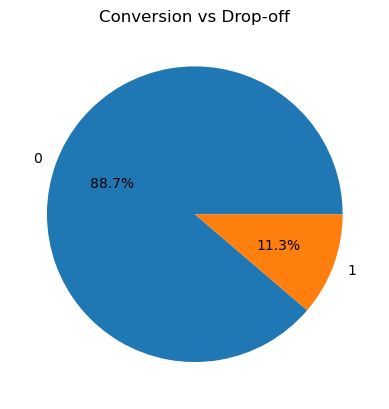

In [32]:
df['converted'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Conversion vs Drop-off")
plt.ylabel("")
plt.show()

In [38]:
# drop-off analysis
# where most users are lost
contacted = len(df)
engaged = df['engaged'].sum()
converted = df['converted'].sum()

print("Engagement Rate:", engaged/contacted)
print("Conversion from Engaged:", converted/engaged)
print("Overall Conversion:", converted/contacted)

Engagement Rate: 0.1365689035641449
Conversion from Engaged: 0.8248888888888889
Overall Conversion: 0.11265417111780131


In [39]:
traffic_to_lead = engaged / contacted
lead_to_customer = converted / engaged

print("Traffic → Lead:", traffic_to_lead)
print("Lead → Customer:", lead_to_customer)

Traffic → Lead: 0.1365689035641449
Lead → Customer: 0.8248888888888889


In [40]:
# which channel brings better engaged users
df.groupby('contact')['engaged'].mean()

contact
cellular     0.199740
telephone    0.026788
Name: engaged, dtype: float64

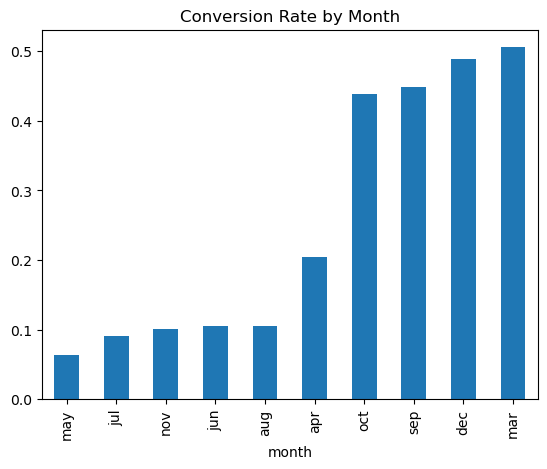

In [42]:
#campaign performance over time
monthly_conversion = df.groupby('month')['converted'].mean().sort_values()
monthly_conversion.plot(kind='bar')
plt.title("Conversion Rate by Month")
plt.show()